In [8]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

sns.set(style="whitegrid")

In [9]:
BASE_PATH = Path(r"E:\Thesis")

# PAD Dataset
PAD_PATH = BASE_PATH / "PAD-UFES-20"
PAD_IMAGE_DIR = PAD_PATH / "images"
PAD_META = PAD_PATH / "metadata.csv"

# Histogram Matched Images
HIST_DIR = BASE_PATH / "PAD_HIST_MATCH_IMPROVED"

# Final Output
OUTPUT_DIR = BASE_PATH / "PAD_HIST_CLAHE_IMPROVED"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# CLAHE Images
CLAHE_DIR = OUTPUT_DIR / "images"
CLAHE_DIR.mkdir(parents=True, exist_ok=True)

# Trained Model
MODEL_PATH = BASE_PATH / "outputs" / "densenet201_baseline" / "best_model.keras"

IMG_SIZE = (250,250)

BATCH_SIZE = 4

CLASS_NAMES=["ACK","BCC","MEL","NEV"]

print(MODEL_PATH.exists())
print(HIST_DIR.exists())
print(PAD_META.exists())

True
True
True


In [10]:
pad = pd.read_csv(PAD_META)

pad_4 = pad[
    pad["diagnostic"].isin(CLASS_NAMES)
].copy()

pad_4["label"]=pad_4["diagnostic"]

print(len(pad_4))

print(pad_4["label"].value_counts())

1871
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [11]:
pad_4["hist_path"] = pad_4["img_id"].apply(
    lambda x: str(HIST_DIR / x)
)

pad_4["exists"] = pad_4["hist_path"].apply(os.path.exists)

print(pad_4["exists"].value_counts())

exists
True    1871
Name: count, dtype: int64


In [12]:
def apply_clahe(image):

    lab=cv2.cvtColor(image,cv2.COLOR_RGB2LAB)

    l,a,b=cv2.split(lab)

    clahe=cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l=clahe.apply(l)

    lab=cv2.merge((l,a,b))

    rgb=cv2.cvtColor(lab,cv2.COLOR_LAB2RGB)

    return rgb

In [13]:
saved=0

for _,row in pad_4.iterrows():

    in_path=Path(row["hist_path"])

    out_path=CLAHE_DIR/in_path.name

    img=cv2.imread(str(in_path))

    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    clahe_img=apply_clahe(img)

    clahe_img=cv2.cvtColor(
        clahe_img,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(str(out_path),clahe_img)

    saved+=1

print("Saved :",saved)

Saved : 1871


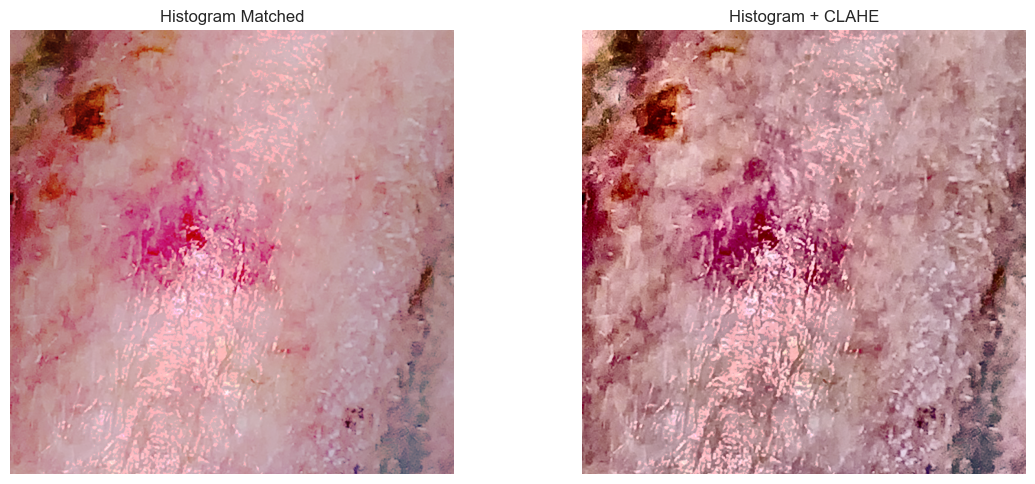

In [14]:
idx=10 if len(pad_4)>10 else 0

hist_path=Path(
    pad_4.iloc[idx]["hist_path"]
)

clahe_path=CLAHE_DIR/hist_path.name

hist=cv2.cvtColor(
    cv2.imread(str(hist_path)),
    cv2.COLOR_BGR2RGB
)

clahe=cv2.cvtColor(
    cv2.imread(str(clahe_path)),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,5))

plt.subplot(121)

plt.imshow(hist)

plt.title("Histogram Matched")

plt.axis("off")

plt.subplot(122)

plt.imshow(clahe)

plt.title("Histogram + CLAHE")

plt.axis("off")

plt.tight_layout()

plt.show()

In [15]:
pad_hist_clahe_df=pad_4.copy()

pad_hist_clahe_df["image_path"]=pad_hist_clahe_df["img_id"].apply(
    lambda x:str(CLAHE_DIR/x)
)

pad_hist_clahe_df["exists"]=pad_hist_clahe_df[
    "image_path"
].apply(os.path.exists)

print(
    pad_hist_clahe_df["exists"].value_counts()
)

exists
True    1871
Name: count, dtype: int64


In [16]:
pad_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

pad_hist_clahe_generator = pad_datagen.flow_from_dataframe(

    dataframe=pad_hist_clahe_df,

    x_col="image_path",

    y_col="label",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    classes=CLASS_NAMES,

    shuffle=False

)

print("Samples :", pad_hist_clahe_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
Samples : 1871


In [17]:
best_model = load_model(MODEL_PATH)

print("Best model loaded successfully.")

Best model loaded successfully.


In [18]:
loss, accuracy = best_model.evaluate(

    pad_hist_clahe_generator,

    verbose=1

)

print()

print("Accuracy :", accuracy)

print("Loss :", loss)

468/468 [==============================] - 153s 281ms/step - loss: 2.0226 - accuracy: 0.4019

Accuracy : 0.40192410349845886
Loss : 2.0225672721862793


In [19]:
pred_probs = best_model.predict(

    pad_hist_clahe_generator,

    verbose=1

)

pred_classes = np.argmax(

    pred_probs,

    axis=1

)

true_classes = pad_hist_clahe_generator.classes

468/468 [==============================] - 111s 218ms/step


In [20]:
acc = accuracy_score(

    true_classes,

    pred_classes

)

prec = precision_score(

    true_classes,

    pred_classes,

    average="macro",

    zero_division=0

)

rec = recall_score(

    true_classes,

    pred_classes,

    average="macro",

    zero_division=0

)

f1 = f1_score(

    true_classes,

    pred_classes,

    average="macro",

    zero_division=0

)

print()

print("Accuracy :",acc)

print("Precision:",prec)

print("Recall :",rec)

print("F1 :",f1)


Accuracy : 0.40192410475681456
Precision: 0.29565856425539067
Recall : 0.3811684530208343
F1 : 0.3067454224065762


In [21]:
print(

    classification_report(

        true_classes,

        pred_classes,

        target_names=CLASS_NAMES,

        zero_division=0

    )

)

              precision    recall  f1-score   support

         ACK       0.28      0.09      0.14       730
         BCC       0.50      0.60      0.55       845
         MEL       0.06      0.13      0.08        52
         NEV       0.34      0.70      0.46       244

    accuracy                           0.40      1871
   macro avg       0.30      0.38      0.31      1871
weighted avg       0.38      0.40      0.36      1871



In [22]:
true_onehot = to_categorical(

    true_classes,

    num_classes=4

)

auc = roc_auc_score(

    true_onehot,

    pred_probs,

    average="macro",

    multi_class="ovr"

)

print()

print("Macro AUC :",auc)


Macro AUC : 0.6378829234429928


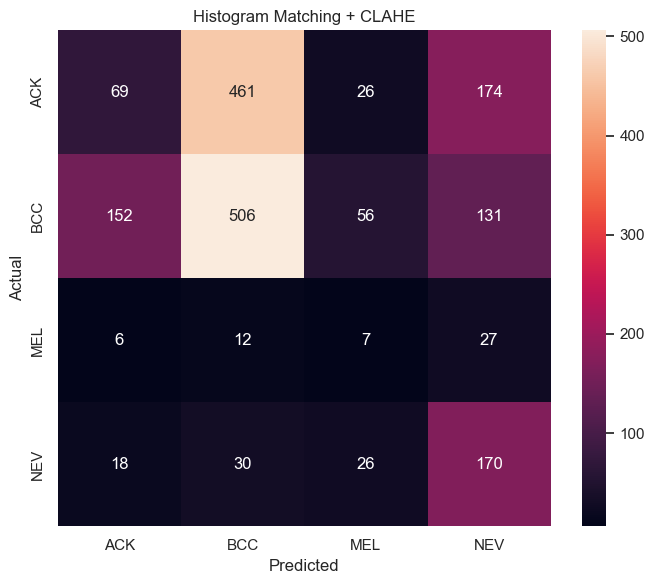

In [23]:
cm = confusion_matrix(

    true_classes,

    pred_classes

)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Histogram Matching + CLAHE")

plt.tight_layout()

plt.show()

In [24]:
results = pd.DataFrame({

    "Experiment":["Histogram Matching + CLAHE"],

    "Accuracy":[acc],

    "Macro Precision":[prec],

    "Macro Recall":[rec],

    "Macro F1":[f1],

    "Macro AUC":[auc]

})

print(results)

results.to_csv(

    OUTPUT_DIR/"hist_clahe_result.csv",

    index=False

)

                   Experiment  Accuracy  Macro Precision  Macro Recall  \
0  Histogram Matching + CLAHE  0.401924         0.295659      0.381168   

   Macro F1  Macro AUC  
0  0.306745   0.637883  
